In [3]:
from src.faster_rcnn.models.thyroid_module import ThyroidDetector
from src.faster_rcnn.datamodules import get_test_transforms
import numpy as np
import pandas as pd
import pydicom
import torch
from scipy import signal

In [2]:
import gradio as gr
from src.faster_rcnn.models.thyroid_module import ThyroidDetector
from src.faster_rcnn.datamodules import get_test_transforms
import numpy as np
import pydicom
import torch
from scipy import signal
import cv2
from PIL import Image

# Common functions
def get_dcm_im(dcm_path):
    img = pydicom.dcmread(dcm_path).pixel_array
    # img = np.concatenate([img[..., None]] * 3, axis=2)
    return img

def irrelevant_cutting(im: np.ndarray, cutting_threshold):
    # Cut irrelevant part of images
    if im.shape[:2] != (512, 512):
        im = im[:cutting_threshold, :cutting_threshold]

    return im

def increase_count(im, factor=1):
    # scharr = np.array([[1, 1, 1],

    #                 [1, 2, 1],

    #                 [1, 1, 1]])*factor
    
    if factor <= 0:
        return im

    scharr = (
        np.array(
            [
                [1, 1, 1, 1, 1],
                [1, 2, 2, 2, 1],
                [1, 2, 4, 2, 1],
                [1, 2, 2, 2, 1],
                [1, 1, 1, 1, 1],
            ]
        )
        * factor
    )

    im = signal.convolve2d(im, scharr, boundary="symm", mode="same")
    # im = ndimage.gaussian_filter(im.astype(np.float32)*1000*factor, sigma=1, mode='reflect').astype(np.uint16)
    im[im < 0] = 0
    im[im > 255] = 255
    return im

def create_imbatch(im: np.ndarray, brighness_levels: int):
    # im shape HxW
    bright_factors = [2**i for i in range(brighness_levels - 1)]
    bright_factors.insert(0, 0) # Original image
    
    im_batch = np.vstack([increase_count(im, factor) for factor in bright_factors]).reshape(brighness_levels, *im.shape)
    im_batch = im_batch.transpose(1, 2, 0) # transpose to HxWxnum_level
    return im_batch.astype(np.uint8)

def draw_box(rgb, color, tl, tf, box, label):
    rgb = rgb.copy()
    if box is None:
        return rgb
    
    img_with_box = cv2.rectangle(rgb, tuple(box[:2]), tuple(box[2:]), color, thickness=tl, lineType=cv2.LINE_AA)
    t_size = cv2.getTextSize(label, 0, fontScale=tl / 3, thickness=tf)[0]
    img_with_box = cv2.rectangle(rgb, (box[0], box[1] - t_size[1] - 3), (box[0] + t_size[0], box[1]), color, -1)
    img_with_box = cv2.putText(
        img_with_box, 
        label,
        (box[0], box[1] - 2), 
        0, 
        tl / 3, 
        (255, 255, 255), 
        thickness=tf,
        lineType=cv2.LINE_AA
    )
    return img_with_box

# Faster-RCNN functions
def create_faster_rcnn_input(img):
    # Prepare input for faster-rcnn
    dummy_bbox = torch.rand(4).unsqueeze(0) + 1
    dummy_bbox[:, 2:4] += dummy_bbox[:, 0:2]
    dummy_labels = torch.tensor([1], dtype=torch.int64)
    params = {"image": img, "bboxes": dummy_bbox, "labels": dummy_labels}
    # Get coressponding faster-rcnn transforms
    faster_rcnn_transforms = get_test_transforms()
    input = faster_rcnn_transforms(**params)["image"]
    
    return input

def get_frcnn_box_scores(pred):
    shoulder_idx = pred['scores'][pred['labels'] == 1].argmax().item() # 1 mean shoulder
    shoulder_score = pred['scores'][pred['labels'] == 1][shoulder_idx]
    thyroid_idx = pred['scores'][pred['labels'] == 2].argmax().item() # 2 mean thyroid
    thyroid_score = pred['scores'][pred['labels'] == 2][thyroid_idx]

    thyroid_box = pred['boxes'][pred['labels'] == 2][thyroid_idx].tolist()
    thyroid_box = [int(c) for c in thyroid_box]
    shoulder_box = pred['boxes'][pred['labels'] == 1][shoulder_idx].tolist()
    shoulder_box = [int(c) for c in shoulder_box]
    
    return shoulder_box, shoulder_score, thyroid_box, thyroid_score

# DETR
import src.detr.datasets.transforms as T

def make_detr_transforms(brighness_levels):
    means = [0.485, 0.456, 0.406]
    stds = [0.229, 0.224, 0.225]
    return T.Compose([
        T.ToTensor(),
        T.Normalize(
            means * (brighness_levels // 3) + means[:brighness_levels % 3], 
            stds * (brighness_levels // 3) + stds[:brighness_levels % 3]
        )
    ])

def create_detr_input(img):    
    input, _ = make_detr_transforms(img.shape[-1])(img, None)
    return input

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h,
                          img_w, img_h
                          ], dtype=torch.float32)
    return b

def get_detr_box_scores(pred):
    probas = pred['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.65

    bboxes_scaled = rescale_bboxes(pred['pred_boxes'][0, keep], (512, 512)).numpy()
    probas, labels = probas.max(-1)
    probas = probas[keep].data.numpy()
    labels = labels[keep].data.numpy()
    shoulder_box = bboxes_scaled[labels == 1][0].astype(np.int32).tolist()
    shoulder_score = probas[labels == 1][0]
    thyroid_box = bboxes_scaled[labels == 2][0].astype(np.int32).tolist()
    thyroid_score = probas[labels == 1][0]
    return shoulder_box, shoulder_score, thyroid_box, thyroid_score

# # Load faster-rcnn model
# faster_rcnn_module = ThyroidDetector(num_level=2, iou_thresholds=[0.5, 0.5])
# faster_rcnn_module = faster_rcnn_module.load_from_checkpoint('/media/vinh/3f144d46-6de0-49c5-aedb-ede7be595d7c/Research/project/models/faster-rcnn/2023-04-23_20-33-55/checkpoints/epoch_011.ckpt', map_location=torch.device('cpu'))
# model = faster_rcnn_module.model
# model.eval()

# def predict(model_name: str, f: gr.components.File, brightness_levels: int):
#     img = irrelevant_cutting(get_dcm_im(f.name), 256)
#     img = create_imbatch(img, brightness_levels).astype(np.float32) / 255.0
#     input = create_faster_rcnn_input(img)
#     with torch.no_grad():
#         pred = model(input.unsqueeze(0))[0]
#         shoulder_box, shoulder_score, thyroid_box, thyroid_score = get_box_scores(pred)
        
#         tl = 1
#         tf = 1
#         rgb = Image.fromarray(input[1].numpy().copy() * 255).convert('RGB')
#         rgb = np.asarray(rgb)

#         label = 'Shoulder {:.2f}'.format(shoulder_score)
#         img_with_box = draw_box(rgb, (0, 0, 255), tl, tf, shoulder_box, label)
#         label = 'Thyroid {:.2f}'.format(thyroid_score)
#         img_with_box = draw_box(img_with_box, (255, 0, 0), tl, tf, thyroid_box, label)
#         img_with_box = Image.fromarray(img_with_box)
#     return img_with_box

In [3]:
imp = "imgs/1.2.840.113619.2.265.1.2.0.10122022070008843.20629.dcm"
img = irrelevant_cutting(get_dcm_im(imp), 256)
img = create_imbatch(img, brighness_levels=4).astype(np.float32) / 255.0

In [246]:
# Load image for yolov7
im = get_dcm_im(imp)
im = irrelevant_cutting(im, 256)
im = increase_count(im, 3)
im = np.stack([im]*3, axis=-1)
im = np.uint8(im)
print(im.shape)

(256, 256, 3)


In [247]:
im = cv2.resize(im.astype(np.float32), (512, 512), interpolation=cv2.INTER_LINEAR) / 255.0
im = im[:, :, ::-1].transpose(2, 0, 1)
im = np.ascontiguousarray(im)
input = torch.from_numpy(im) 

In [4]:
input = create_detr_input(img)

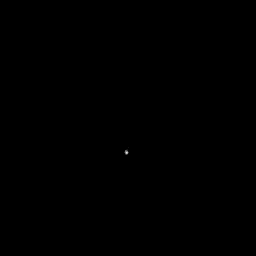

In [17]:
# import matplotlib.pyplot as plt
Image.fromarray(input[1].numpy().copy() * 255).convert('RGB')

In [30]:
from src.detr.models import build_model
from easydict import EasyDict
from src.detr.models.backbone import build_backbone
from src.detr.models.transformer import build_transformer
from src.detr.models.detr import DETR

def get_args_parser():
    args = {}
    args['frozen_weights'] = None
    # * Backbone
    args['lr_backbone']=1e-5
    args['backbone']='resnet50'
    args['dilation'] = False
    args['brighness_levels']=4
    args['position_embedding']='sine'

    # * Transformer
    args['enc_layers']=6
    args['dec_layers']=6
    args['dim_feedforward']=2048
    args['hidden_dim']=256
    args['dropout']=0.1
    args['nheads']=8
    args['num_queries']=75
    args['pre_norm'] = False
    
    args['thresh']=0.65

    # * Segmentation
    args['masks'] = False
    return EasyDict(args)

# model, criterion, postprocessors = build_model(get_args_parser())
# checkpoint = torch.load(args.resume, map_location='cpu')
args = get_args_parser()
backbone = build_backbone(args)
transformer = build_transformer(args)

model = DETR(
    backbone,
    transformer,
    num_classes=3,
    num_queries=75,
    aux_loss=True,
)
checkpoint = torch.load('/media/vinh/3f144d46-6de0-49c5-aedb-ede7be595d7c/Research/project/models/detr/output/resnet50_75nq_coscl2_4bl/resnet50_75nq_coscl2_4bl.pth', map_location='cpu')
model.load_state_dict(checkpoint['model'])

/home/vinh/anaconda3/envs/rs/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vinh/anaconda3/envs/rs/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [1]:
import sys
sys.path.insert(0, './src/yolov7')

In [2]:
# Load yolov7
from models.experimental import attempt_load
from utils.general import scale_coords, non_max_suppression
# import torch

file = '/media/vinh/3f144d46-6de0-49c5-aedb-ede7be595d7c/Research/project/models/yolov7/3bl.pt'
model = attempt_load(file, map_location='cpu')

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


/home/vinh/anaconda3/envs/rs/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [147]:
names = model.module.names if hasattr(model, 'module') else model.names

In [248]:
model.eval()
with torch.no_grad():
    pred = model(input.unsqueeze(0))

In [249]:
def get_yolov7_box_scores(pred):
    out = pred[0] # Return both prediction and losss -> Get prediction at position 0
    out = non_max_suppression(out, conf_thres=0.25, iou_thres=0.65)
    shapes = ((512, 512), ((1.0, 1.0), (0.0, 0.0)))
    predn = out[0].clone()
    predn[:, :4] = scale_coords(input.shape[1:], predn[:, :4], shapes[0], shapes[1]).round()
    # Get bounding box that have maximum probability
    labels = predn[:, -1]
    scores = predn[:, -2]
    boxes = predn[:, :4]
    
    if torch.sum(labels == 0) > 0:
        shoulder_idx = scores[labels == 0].argmax()
        shoulder_score = scores[labels == 0][shoulder_idx].item()
        shoulder_box = boxes[labels == 0][shoulder_idx].type(torch.int32).tolist()
    else:
        shoulder_score = -1
        shoulder_box = None
    
    if torch.sum(labels == 1) > 0:
        thyroid_idx = scores[labels == 1].argmax()
        thyroid_score = scores[labels == 1][thyroid_idx].item()
        thyroid_box = boxes[labels == 1][thyroid_idx].type(torch.int32).tolist()
    else:
        thyroid_score = -1
        thyroid_box = None

    return shoulder_box, shoulder_score, thyroid_box, thyroid_score

In [250]:
shoulder_box, shoulder_score, thyroid_box, thyroid_score = get_yolov7_box_scores(pred)

In [83]:
shoulder_box, shoulder_score, thyroid_box, thyroid_score = get_detr_box_scores(pred)

In [251]:
rgb = Image.fromarray(im[1].copy() * 255).convert('RGB')
rgb = np.asarray(rgb)
label = 'Shoulder {:.2f}'.format(shoulder_score)

tl = 1
tf = 1
img_with_box = draw_box(rgb, (0, 0, 255), tl, tf, shoulder_box, label)
label = 'Thyroid {:.2f}'.format(thyroid_score)
img_with_box = draw_box(img_with_box, (255, 0, 0), tl, tf, thyroid_box, label)
img_with_box = Image.fromarray(img_with_box)

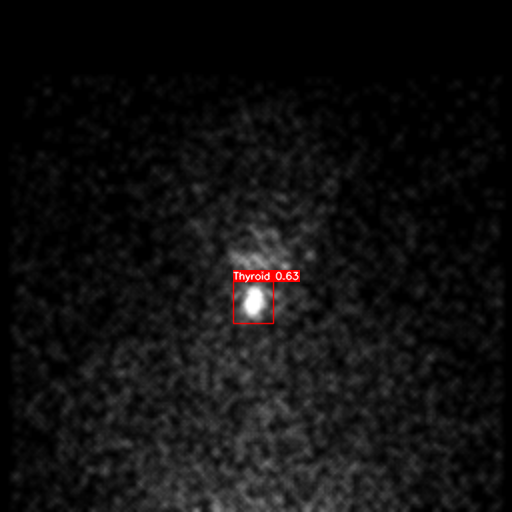

In [252]:
img_with_box

In [63]:
probas[labels ==2 ][0]

0.99704665

In [68]:
bboxes_scaled[labels == 1][0].astype(np.int32).tolist()

[114, 254, 147, 286]

In [4]:
def create_faster_rcnn_input(img):
    # Prepare input for faster-rcnn
    dummy_bbox = torch.rand(4).unsqueeze(0) + 1
    dummy_bbox[:, 2:4] += dummy_bbox[:, 0:2]
    dummy_labels = torch.tensor([1], dtype=torch.int64)
    params = {"image": img, "bboxes": dummy_bbox, "labels": dummy_labels}
    # Get coressponding faster-rcnn transforms
    faster_rcnn_transforms = get_test_transforms()
    input = faster_rcnn_transforms(**params)["image"]
    
    return input

input = create_faster_rcnn_input(img)

In [5]:
# Load faster-rcnn model
faster_rcnn_module = ThyroidDetector(num_level=2, iou_thresholds=[0.5, 0.5])
faster_rcnn_module = faster_rcnn_module.load_from_checkpoint('/media/vinh/3f144d46-6de0-49c5-aedb-ede7be595d7c/Research/project/models/faster-rcnn/2023-04-23_20-33-55/checkpoints/epoch_011.ckpt', map_location=torch.device('cpu'))

In [6]:
model = faster_rcnn_module.model
model.eval()
pred = model(input.unsqueeze(0))[0]

In [141]:
def get_box_scores(pred):
    shoulder_idx = pred['scores'][pred['labels'] == 1].argmax().item() # 1 mean shoulder
    shoulder_score = pred['scores'][pred['labels'] == 1][shoulder_idx]
    thyroid_idx = pred['scores'][pred['labels'] == 2].argmax().item() # 2 mean thyroid
    thyroid_score = pred['scores'][pred['labels'] == 2][thyroid_idx]

    thyroid_box = pred['boxes'][pred['labels'] == 2][thyroid_idx].tolist()
    thyroid_box = [int(c) for c in thyroid_box]
    shoulder_box = pred['boxes'][pred['labels'] == 1][shoulder_idx].tolist()
    shoulder_box = [int(c) for c in shoulder_box]
    
    return shoulder_box, shoulder_score, thyroid_box, thyroid_score

def draw_box(rgb, color, tl, tf, box, label):
    rgb = rgb.copy()
    img_with_box = cv2.rectangle(rgb, tuple(box[:2]), tuple(box[2:]), color, thickness=tl, lineType=cv2.LINE_AA)
    t_size = cv2.getTextSize(label, 0, fontScale=tl / 3, thickness=tf)[0]
    img_with_box = cv2.rectangle(rgb, (box[0], box[1] - t_size[1] - 3), (box[0] + t_size[0], box[1]), color, -1)
    img_with_box = cv2.putText(
        img_with_box, 
        label,
        (box[0], box[1] - 2), 
        0, 
        tl / 3, 
        (255, 255, 255), 
        thickness=tf,
        lineType=cv2.LINE_AA
    )
    return img_with_box


import cv2
from PIL import Image
import math

shoulder_box, shoulder_score, thyroid_box, thyroid_score = get_box_scores(pred)

tl = 1
tf = 1
rgb = Image.fromarray(input[1].numpy().copy() * 255).convert('RGB')
rgb = np.asarray(rgb)

label = 'Shoulder {:.2f}'.format(shoulder_score)
img_with_box = draw_box(rgb, (0, 0, 255), tl, tf, shoulder_box, label)
label = 'Thyroid {:.2f}'.format(thyroid_score)
img_with_box = draw_box(img_with_box, (255, 0, 0), tl, tf, thyroid_box, label)
img_with_box = Image.fromarray(img_with_box)

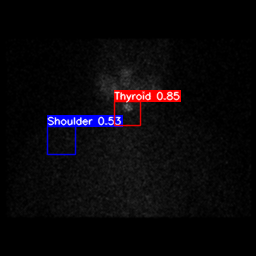

In [142]:
img_with_box

In [16]:
img_with_box.size

(512, 512)